# Lab 3.1 - Linear Regression (Part 1)
This is the first part of the linear regression lab that will cover:
- Linear regression inference
- Cost functions
- Closed form solutions
- Basis functions
  - Radial basis functions 

## Instructions
- Run all the code cells.
- Put your names and student numbers in the indicated cell in the **exact** indicated format.
- You cannot use additional libraries to the ones imported already for you
- Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
     - Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
- Do not delete the answer code cells and recreate them as they have custom metadata used by the automarker. If you accidentally delete one then you must redownload the notebook from Moodle.
- You will be explicitly instructed which variables from previous code blocks you can use. You may use intermediary variables within a single answer code block but ensure that everything is self contained within a code block except for the variables or functions you are told to use from previous code blocks. You will always have access to functions or variables defined for you in previous code blocks.

**This lab will be automarked and as such failure to exactly follow instructions will likely result in the automarker giving you zero for the associated parts of the lab.**

### Public Test Cases
The 'public test cases' are used for you to check your answers. Hidden test cases will be used to calculate your mark. 

## Student Details

Fill in your names and student numbers in the fields below. This is used for the automarker, so if you do this incorrectly **you will recieve zero** as your submission will not be recognised.

**Note:** `student_names[0]` should correspond to the same student as `student_nos[0]` and similarly for the other students indicated.

In [1]:
# STUDENT DETAILS
student_names = []  # List of strings containing student names
student_nos = []  # List of strings containing student nos

assert len(student_names) == len(student_nos)

## Imports

You are **not allowed** to import additional libraries to the ones specified below

In [2]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set()

# Section 1
In the first part of this lab we will not use basis functions and will instead use the feature vector $\mathbf{x}$ directly. That is we will model $\hat{y}=f(\mathbf{x}, \mathbf{\theta})$ as follows:

$$ 
\begin{align}
    \hat{y} = f(\mathbf{x}, \theta) &= \sum_{i=0}^d \theta_i x_i \\
                          &= \mathbf{\theta}^T \mathbf{x}
\end{align}
$$

Here $\hat{y}$ is used to signify that it is an approximate of the label associated with $\mathbf{x}$ rather than the true label which we will denote $y$.

### Data Generation
We first create the data $\mathbf{X}$, with $d=10$ and 20 data points.

In [3]:
# DO NOT MODIFY
np.random.seed(42)
X = np.random.rand(20, 10)
X

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
        0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258],
       [0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
        0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914],
       [0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998,
        0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041],
       [0.60754485, 0.17052412, 0.06505159, 0.94888554, 0.96563203,
        0.80839735, 0.30461377, 0.09767211, 0.68423303, 0.44015249],
       [0.12203823, 0.49517691, 0.03438852, 0.9093204 , 0.25877998,
        0.66252228, 0.31171108, 0.52006802, 0.54671028, 0.18485446],
       [0.96958463, 0.77513282, 0.93949894, 0.89482735, 0.59789998,
        0.92187424, 0.0884925 , 0.19598286, 0.04522729, 0.32533033],
       [0.38867729, 0.27134903, 0.82873751, 0.35675333, 0.28093451,
        0.54269608, 0.14092422, 0.80219698, 0.07455064, 0.98688694],
       [0.77224477, 0.19871568, 0.0055221

Next we will generate the true labels $y$ associated with each $\mathbf{x} \in \mathbf{X}$. We define the true model as:
$$
y = \sum_{i=0}^d \theta^*_i x_i + \eta
$$
where $\theta^*$ is the parameters associated with the true function and $\eta$ is gaussian noise. $\theta^*$ is represented with the Numpy array `true_theta`.

**Note:** Usually you will not have access to the true model and will only have the data and true labels.

In [4]:
# DO NOT MODIFY
true_theta = np.array([0.902, 0.558, 0.656, 0.832, 0.2, 0.127, 0.771, 0.432, 0.385, 0.784, 0.786])
true_theta

array([0.902, 0.558, 0.656, 0.832, 0.2  , 0.127, 0.771, 0.432, 0.385,
       0.784, 0.786])

When calculating $y$ we make the assumption that $x_0 = 1$. Thus, we create a new variable `X_aug` which is simply $X$ augmented with a new column of ones for the first column.

In [5]:
# DO NOT MODIFY
X_aug = np.concatenate([np.ones((20, 1)), X], axis=1)
print("First 4 rows of X_aug:")
print(X_aug[:4])
# np.matmul(X[0].T, true_theta)

First 4 rows of X_aug:
[[1.         0.37454012 0.95071431 0.73199394 0.59865848 0.15601864
  0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [1.         0.02058449 0.96990985 0.83244264 0.21233911 0.18182497
  0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]
 [1.         0.61185289 0.13949386 0.29214465 0.36636184 0.45606998
  0.78517596 0.19967378 0.51423444 0.59241457 0.04645041]
 [1.         0.60754485 0.17052412 0.06505159 0.94888554 0.96563203
  0.80839735 0.30461377 0.09767211 0.68423303 0.44015249]]


Finally we generate the labels $y$ using 
$$
y = {\theta^*}^T + \eta
$$
where in this particular case $\eta$ represents an array of gaussian noise.

In [6]:
# DO NOT MODIFY
np.random.seed(42)
eta = np.random.normal(scale=0.1, size=(20))
y = np.matmul(X_aug, true_theta) + eta
y

array([4.03955934, 3.3364922 , 3.16452139, 3.54658196, 2.93446495,
       4.08027858, 3.87363175, 3.09334183, 3.95116298, 3.20989114,
       2.66946109, 4.35304548, 3.70108238, 3.16916622, 2.68646267,
       3.38225351, 3.41726536, 3.29998729, 3.73450475, 4.55681823])

**Important:** Do not modify or redefine `X`, `true_theta`, `approx_theta` or `X_aug`. 

## Question 1
Predict $f(\mathbf{x}^0, \mathbf{\theta})$ where $\mathbf{x}^0$ corresponds to `X_aug[0]` and $\mathbf{\theta}$ corresponds to `approx_theta`. Set $f(\mathbf{x}^0, \mathbf{\theta})$ to the variable `s1_q1_ans`.

In [7]:
# DO NOT MODIFY
approx_theta = np.array([0.702, 0.5, 0.34, 0.2, 0.2  , 0.23, 0.771, 0.239, 0.320, 0.812, 0.904])
approx_theta

array([0.702, 0.5  , 0.34 , 0.2  , 0.2  , 0.23 , 0.771, 0.239, 0.32 ,
       0.812, 0.904])

In [8]:
# STUDENT ANSWER
# Hint: Use np.matmul
s1_q1_ans = np.matmul(X_aug[0], approx_theta)

print(s1_q1_ans)  # Do not remove

3.0540608211050033


#### Public Test Case

In [9]:
if np.round(s1_q1_ans, 2) == 3.05:
    print("Q1 Test Case Passed")
else:
    print("Q1 Test Case Failed")

Q1 Test Case Passed


## Question 2
### a)
Now compute the error of `approx_theta` using
$$
E(\theta) = \frac{1}{2}\sum_{n=1}^{N}(\hat{y}^n - y^n)^2
$$
where $\hat{y}^n$ denotes the predicted label for the datapoint $n$ and $y^n$ denotes the associated true label.

Note: first compute the predicted value $\hat{y}$ associated with each $\mathbf{x} \in \mathbf{X}$. 

The computed error of `approx_theta` must be set to the variable `s1_q2_a_ans`.

In [15]:
# STUDENT ANSWER
# Note: Do NOT redefine or modify X_aug, approx_theta or y 
s1_q2_a_ans = 0.0

approx = np.matmul(X_aug, approx_theta)

for a, _y in zip(approx, y):
    s1_q2_a_ans += (a - _y)**2
s1_q2_a_ans /= 2

print(s1_q2_a_ans)  # Do not remove

5.5120820284351995


#### Public Test Case

In [14]:
if np.round(s1_q2_a_ans, 2) == 5.51:
    print("S1 Q2 a) Test Case Passed")
else:
    print("S1 Q2 a) Test Case Failed")

S1 Q2 a) Test Case Passed


### b)
Now compute the error associated with the theta our true labels were generated with (i.e. `true_theta`) and set it to the variable `s1_q2_b_error`. Note that there is no public test case for this part of the answer.

In [17]:
# STUDENT ANSWER
s1_q2_b_error = 0.0

true = np.matmul(X_aug, true_theta)

for t, _y in zip(true, y):
    s1_q2_b_error += (t - _y)**2
s1_q2_b_error /= 2

print(s1_q2_b_error)  # Do not remove

0.09049150386242143


Which of the following options is true? 
- a) The error for `true_theta` is exactly zero because the closed form solution gives the exact solution for $\theta$
- b) The error for `true_theta` is close to zero because the closed form solution gives an approximate solution that is computed by minimising the associated cost 
- c) The error for `true_theta` is zero because the closed form solution minimises the associated cost and the minimum cost will always be zero
- d) The error for `true_theta` is not zero because the sum of `true_theta` is not zero

Set the variable `s1_q2_b_ans` to "a", "b", "c" or "d" to denote your answer. There is only one correct answer.

In [18]:
# STUDENT ANSWER
s1_q2_b_ans = "b"  # Set your answer here

# DO NOT REMOVE OR MODIFY
# Validate that your answer is in correct format
if s1_q2_b_ans in ["a", "b", "c", "d"]:
    print("s1_q2_b_ans is in correct format")
else:
    print("s1_q2_b_ans is NOT in correct format")

s1_q2_b_ans is in correct format


## Question 3
Compute the closed form solution of $\theta$ using
$$
\begin{align}
\mathbf{\theta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
\end{align}
$$
and set $\mathbf{\theta}$ to the variable `s1_q3_ans`.

Notes: 
- If we are not using basis functions and are instead using just the original features present in the dataset then the design matrix $\mathbf{X}$ is simply the original data augmented such that the first column is just ones.
- The inverse of a matrix can be computing using `np.linalg.inv`. See https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html 

In [21]:
# STUDENT ANSWER
s1_q3_ans = np.matmul(np.linalg.inv(np.matmul(X_aug.T, X_aug)), np.matmul(X_aug.T, y))

print(s1_q3_ans)  # Do not remove

[0.89655388 0.58203046 0.64609315 0.82087319 0.13181338 0.1722691
 0.90802853 0.271815   0.43107095 0.82728786 0.71468358]


#### Public Test Case

In [22]:
true_s1_q3_ans = np.array([0.897, 0.582, 0.646, 0.821, 0.132, 0.172, 0.908, 0.272, 0.431, 0.827, 0.715])

if np.array_equal(np.round(s1_q3_ans, 3), true_s1_q3_ans):
    print("S1 Q3 Test Case Passed")
else:
    print("S1 Q3 Test Case Failed")

S1 Q3 Test Case Passed


# Section 2 - Gaussian Basis Functions
This section focuses on gaussian basis functions or otherwise known as radial basis functions.

## Load Data & Targets

We use 1 dimensional data which is stored in the variable `s2_data`.

In [25]:
# DO NOT MODIFY
with open("s2_data.npy", "rb") as f:
    s2_data = np.load(f)

with open("s2_y.npy", "rb") as f:
    s2_y = np.load(f)

print(f"s2_data.shape = {s2_data.shape}")
print(f"s2_y.shape = {s2_y.shape}\n")

print(f"First 5 elements of s2_data = \n{s2_data[:5]}")
print(f"\nFirst 5 elements of s2_y = \n{s2_y[:5]}")

s2_data.shape = (42,)
s2_y.shape = (42,)

First 5 elements of s2_data = 
[-1.   -0.95 -0.9  -0.85 -0.8 ]

First 5 elements of s2_y = 
[1.41006244 1.71158637 2.33839577 2.97838197 3.08434193]


The dataset is visualised for you below 

<Axes: >

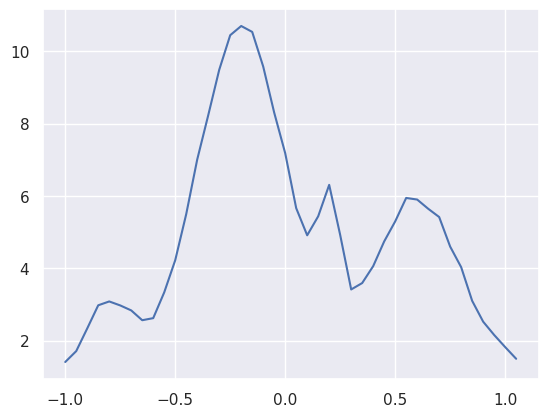

In [26]:
sns.lineplot(x=s2_data, y=s2_y)

## Gaussian/Radial Basis Functions

A gaussian/radial basis function $\phi_j(x)$ has the form
$$
\phi_j(x) = e^{-\frac{1}{2\sigma^2}(x-\mu_j)^2}
$$
where,
- $x$ is the 1 dimensional feature value
- $\mu_j$ is the location (mean)
- $\sigma$ is the scale/width (standard deviation)

The function `radial_basis_function` implements this. It takes in the arguments
- `x`
- `loc`
- `scale`

and returns the associated value of the basis function for that `x`.

In [27]:
# DO NOT MODIFY
def radial_basis_function(x, loc, scale):
    return np.exp(-1 * 1/(2*scale**2)*(x - loc)**2)

print(f"Value of radial basis function with loc=0 and scale=0.1 for x={0.01} is {radial_basis_function(0.01, 0, 0.1)}")

Value of radial basis function with loc=0 and scale=0.1 for x=0.01 is 0.9950124791926823


This basis function can be applied to each element of the numpy array `s2_data` using the function `np.apply_along_axis` ([see docs](https://numpy.org/doc/2.0/reference/generated/numpy.apply_along_axis.html)) as shown below for the basis function $\phi_1$. We chose $\phi_1$ to be the radial basis function with $\mu_1=0$ and $\sigma=0.1$.

The values of this basis function are visualised for you.

phi_1 = 
[1.92874985e-22 2.52616378e-20 2.57675711e-18 2.04697171e-16
 1.26641655e-14 6.10193668e-13 2.28973485e-11 6.69158609e-10
 1.52299797e-08 2.69957850e-07 3.72665317e-06 4.00652974e-05
 3.35462628e-04 2.18749112e-03 1.11089965e-02 4.39369336e-02
 1.35335283e-01 3.24652467e-01 6.06530660e-01 8.82496903e-01
 1.00000000e+00 8.82496903e-01 6.06530660e-01 3.24652467e-01
 1.35335283e-01 4.39369336e-02 1.11089965e-02 2.18749112e-03
 3.35462628e-04 4.00652974e-05 3.72665317e-06 2.69957850e-07
 1.52299797e-08 6.69158609e-10 2.28973485e-11 6.10193668e-13
 1.26641655e-14 2.04697171e-16 2.57675711e-18 2.52616378e-20
 1.92874985e-22 1.14687658e-24]


<Axes: >

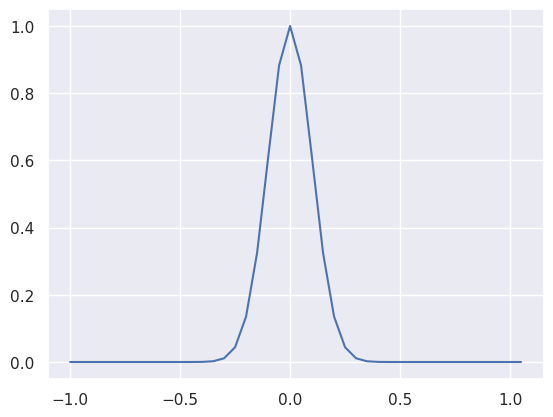

In [28]:
# DO NOT MODIFY
phi_1 = np.apply_along_axis(radial_basis_function, 0, s2_data, loc=0, scale=0.1)
print(f"phi_1 = \n{str(phi_1)}")
sns.lineplot(x=s2_data, y=phi_1)

## Question 1

Calculate the design matrix given below and assign your answer to the variable `s2_q1_ans`.

$$
\Phi = \begin{bmatrix}
\phi_0(x^{(1)}) & \phi_1(x^{(1)}) & \phi_2(x^{(1)}) & \phi_3(x^{(1)}) & \phi_4(x^{(1)}) \\
\phi_0(x^{(2)}) & \phi_1(x^{(2)}) & \phi_2(x^{(2)}) & \phi_3(x^{(2)}) & \phi_4(x^{(2)}) \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
\phi_0(x^{(n)}) & \phi_1(x^{(n)}) & \phi_2(x^{(n)}) & \phi_3(x^{(n)}) & \phi_4(x^{(n)})
\end{bmatrix}
$$

As usual the first basis function ($\phi_0$) just consists of the value 1. The other basis functions are radial basis functions with the following locations and scales:
- $\phi_1$: $\mu_1=-0.8, \sigma_1=0.1$
- $\phi_2$: $\mu_2=-0.2, \sigma_2=0.2$
- $\phi_3$: $\mu_3=0.2, \sigma_3=0.05$
- $\phi_4$: $\mu_4=0.6, \sigma_4=0.2$

Hint: Use `np.apply_along_axis` with `radial_basis_function` or `np.ones`

In [48]:
# STUDENT ANSWER
s2_q1_ans = np.zeros((42, 5), dtype=float)  # DO NOT REDEFINE THIS OR RENAME

# TODO: Your answer
s2_q1_ans[:, 0] = np.ones((42), dtype=float)
s2_q1_ans[:, 1] = np.apply_along_axis(radial_basis_function, 0, s2_data, loc=-0.8, scale=0.1)
s2_q1_ans[:, 2] = np.apply_along_axis(radial_basis_function, 0, s2_data, loc=-0.2, scale=0.2)
s2_q1_ans[:, 3] = np.apply_along_axis(radial_basis_function, 0, s2_data, loc=0.2, scale=0.05)
s2_q1_ans[:, 4] = np.apply_along_axis(radial_basis_function, 0, s2_data, loc=0.6, scale=0.2)
# DO NOT MODIFY BELOW
print(f"first 5 rows of s2_q1_ans = \n{s2_q1_ans[:5]}")  
if s2_q1_ans.shape != (42, 5):
    raise ValueError("s2_q1_ans was redefined and is of the wrong shape")

first 5 rows of s2_q1_ans = 
[[1.00000000e+000 1.35335283e-001 3.35462628e-004 8.37894253e-126
  1.26641655e-014]
 [1.00000000e+000 3.24652467e-001 8.83826307e-004 1.34619985e-115
  9.06971918e-014]
 [1.00000000e+000 6.06530660e-001 2.18749112e-003 7.95674389e-106
  6.10193668e-013]
 [1.00000000e+000 8.82496903e-001 5.08606923e-003 1.73008221e-096
  3.85654273e-012]
 [1.00000000e+000 1.00000000e+000 1.11089965e-002 1.38389653e-087
  2.28973485e-011]]


### Public Test Case
This checks if the first four rows of `s1_q1_ans` are correct within a desired tolerance for decimals.

In [49]:
ptc_s2_q1_ans = np.array([
    [1.   , 0.135, 0.   , 0.   , 0.   ],
    [1.   , 0.325, 0.001, 0.   , 0.   ],
    [1.   , 0.607, 0.002, 0.   , 0.   ],
    [1.   , 0.882, 0.005, 0.   , 0.   ]
])

if np.array_equal(np.round(s2_q1_ans[:4], 3), ptc_s2_q1_ans):
    print("Public Test Case Passed")
else:
    print("Public Test Case Failed")

Public Test Case Passed


## Question 2
Using `s1_q1_ans` as the design matrix compute the closed form solution of $\mathbf{\theta}$. Set $\theta$ to the variable `s2_q2_ans`. Use the following equation, where $X$ is the design matrix.

$$
\begin{align}
\mathbf{\theta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
\end{align}
$$

Note: `s2_q2_ans` must be a numpy array of shape `(5,)`.

In [53]:
# STUDENT ANSWER
design_matrix = s1_q1_ans  # DO NOT MODIFY

# TODO: Your answer
# You MUST use the variable s2_y for the y value
s2_q2_ans = np.matmul(np.linalg.inv(np.matmul(s2_q1_ans.T, s2_q1_ans)), np.matmul(s2_q1_ans.T, s2_y))

# DO NOT MODIFY BELOW
print(f"s2_q2_ans = {s2_q2_ans}")
if type(s2_q2_ans) != np.ndarray:
    raise TypeError(f"s2_q2_ans is of wrong type")
if s2_q2_ans.shape != (5,):
    raise TypeError(f"s2_q2_ans is of wrong shape")

s2_q2_ans = [1.10418294 1.96704131 9.61603241 3.23375114 4.77147569]


### Public Test Case

In [54]:
ptc_s2_s2 = np.array([1.104, 1.967, 9.616, 3.234, 4.771])

if np.array_equal(np.round(s2_q2_ans, 3), ptc_s2_s2):
    print("Public Test Case Passed")
else:
    print("Public Test Case Failed")

Public Test Case Passed


## Question 3
Using your estimate of $\theta$ computed in Question 2 predict the associated target for each datapoint. That is compute the vector $\hat{y}$. Set your answer to the variable `s2_q3_ans` which must be a numpy array of shape `(42,)`.

Note: Only use the design matrix (the variable `s2_q1_ans`) and your estimate of the parameters (the variable `s2_q2_ans`). 

In [55]:
# STUDENT ANSWER
# Hint: Use np.matmul
s2_q3_ans = np.matmul(s2_q1_ans, s2_q2_ans)


# DO NOT MODIFY BELOW
print(f"s2_q3_ans = {s2_q3_ans}")
if type(s2_q3_ans) != np.ndarray:
    raise TypeError(f"s2_q3_ans is of wrong type")
if s2_q3_ans.shape != (42,):
    raise TypeError(f"s2_q3_ans is of wrong shape")

s2_q3_ans = [ 1.37361885  1.75128666  2.31828879  2.88899861  3.17804872  3.05928039
  2.71975279  2.50783459  2.67178158  3.27022187  4.24790473  5.51103121
  6.93727908  8.36288399  9.59050026 10.4249324  10.72181604 10.4285783
  9.60073937  8.38702513  6.99069253  5.651409    4.87333623  5.52478127
  6.28507156  4.86250295  3.5133939   3.54383701  4.10613851  4.75480161
  5.33603049  5.73735466  5.87888445  5.73000596  5.31538072  4.70600298
  3.99826507  3.28873365  2.65325689  2.13608756  1.7499321   1.48379923]


### Public Test Case

In [56]:
ptc_s2_q3 = np.array([ 
    1.374,  1.751,  2.318,  2.889,  3.178,  3.059,  2.72 ,  2.508,
    2.672,  3.27 ,  4.248,  5.511,  6.937,  8.363,  9.591, 10.425,
    10.722, 10.429,  9.601,  8.387,  6.991,  5.651,  4.873,  5.525,
    6.285,  4.863,  3.513,  3.544,  4.106,  4.755,  5.336,  5.737,
    5.879,  5.73 ,  5.315,  4.706,  3.998,  3.289,  2.653,  2.136,
    1.75 ,  1.484
])

if np.array_equal(np.round(s2_q3_ans, 3), ptc_s2_q3):
    print("Public Test Case Passed")
else:
    print("Public Test Case Failed")

Public Test Case Passed


### Visualise Data
If your code is correct then $y$ and $\hat{y}$ should be almost identical. 

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_42875/3734718948.py:3: SyntaxWarning: invalid escape sequence '\h'
  sns.lineplot(x=s2_data, y=s2_q3_ans, ax=ax, label="$\hat{y}$")


Text(0.5, 0, 'x')

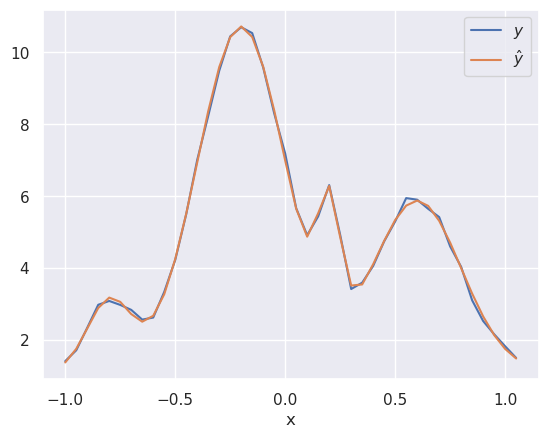

In [57]:
fig, ax = plt.subplots(1)
sns.lineplot(x=s2_data, y=s2_y, ax=ax, label="$y$")
sns.lineplot(x=s2_data, y=s2_q3_ans, ax=ax, label="$\hat{y}$")
ax.set_xlabel("x")

## Question 4
Finally compute the error of $\theta$ using
$$
E(\theta) = \frac{1}{2}\sum_{n=1}^{N}(\hat{y}^n - y^n)^2
$$
where,
- $\theta$ = `s2_q2_ans`
- $\hat{\mathbf{y}}$ = `s2_q3_ans`
- $\mathbf{y}$ = `s2_y`

Set $E(\theta)$ to the variable `s2_q4_ans`.

In [58]:
# STUDENT ANSWER
s2_q4_ans = 0.0

for estimate, t in zip(s2_q3_ans, s2_y):
    s2_q4_ans += (estimate - t)**2
s2_q4_ans /= 2

# DO NOT MODIFY BELOW
print(f"s2_q4_ans = {s2_q4_ans}")

s2_q4_ans = 0.1510000240668547


### Public Test Case

In [59]:
ptc_s2_q4 = 0.151
if np.round(s2_q4_ans, 3) == ptc_s2_q4:
    print("Public Test Case Passed")
else:
    print("Public Test Case Failed")

Public Test Case Passed


# END